In [2]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 设置路径（假设 notebook 在 notebooks/ 下）
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

from src.detection.auto_sensitive import detect_sensitive_attributes

In [3]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

In [4]:
data_path = os.path.join(project_root, "data", "raw", "adult.data")
df = pd.read_csv(data_path, header=None, names=columns, na_values=" ?", skipinitialspace=True)
df.dropna(inplace=True)
df["label"] = df["income"].apply(lambda x: 1 if ">50K" in x else 0)

In [5]:
# 运行敏感属性识别
result = detect_sensitive_attributes(
    df,
    candidate_columns=["sex", "race", "age", "education"],
    label_column="label",
    prediction_column=None,  # 用真实标签代替预测概率
    threshold=0.1
)

In [6]:
print("\n识别出的敏感属性 (Score ≥ 0.1):")
for attr, score in result:
    print(f"- {attr} | Score: {score:.4f}")


识别出的敏感属性 (Score ≥ 0.1):
- education | Score: 13.5156
- age | Score: 12.9798
- race | Score: 1.0576


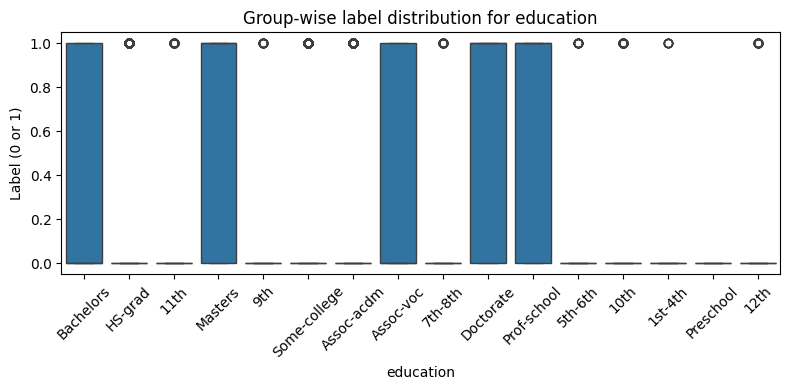

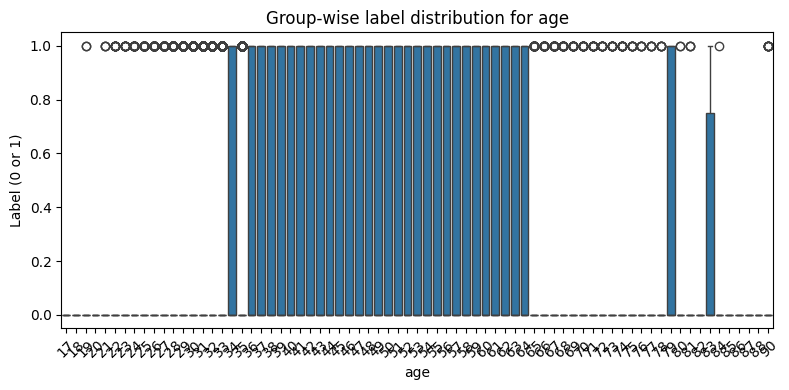

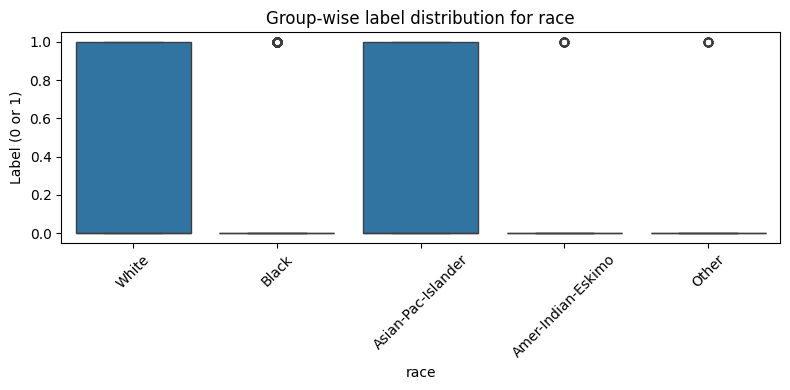

In [7]:
# 可视化前3个敏感属性的标签分布（真实值）
for attr, _ in result[:3]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=attr, y="label")
    plt.title(f"Group-wise label distribution for {attr}")
    plt.ylabel("Label (0 or 1)")
    plt.xlabel(attr)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
